# *Pós-graduação em Ciência e Dados e Machine Learning*
### *Trabalho Final - Machine Learning*

**Disciplina:** Fundamentos de Machine Learning

**Professor:** André Juan Costa Vieira

**Turma:** A

**Nomes dos Integrantes:** 

1-

2-

3-

### Modelos não Supervisionados

**Utilize o dataset 'wines.csv' e 'wines_splines.csv'**

Chuck Norris tem um amigo famoso no mundo da ciência de dados, seu nome é Rocky Balboa. Em uma conversa sobre alguns métodos que podem ser utilizados para criar novos vetores (_features engineering_), o Sr.Rocky propôs que fossem utilizados Splines. Completamente emocionado com a ideia, Chuck decidiu aplicar esta técnica utilizando até a oitava potência. 

Ele pediu a você que fizesse um estudo comparativo utilizando o PCA. O intuito é analisar se a redução de dimensionalidade pode ser vantajosa para o dataset original e o dataset com Splines. 

1- Compare a variância explicada de cada um dos datasets

2- Explique porque o PCA seria, ou não uma boa abordagem para o dataset com Splines. Ademais, discorra sobre a influência de ruídos.

3- Utilize um loop "for" e crie uma condição para que, quando a variância for maior do que 0.92, seja retornado o número de features totais, faça para ambos datasets.

4- Qual seria o método mais indicado para redução de dimensionalidade nesse caso? 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('../../data/trabalho_ML2/wines.csv')
df_spl = pd.read_csv('../../data/trabalho_ML2/wines_splines.csv')

print('duplicadas:', df.duplicated().sum(), df_spl.duplicated().sum())
df = df.drop_duplicates()  # mesmo criterio do trabalho de ml 1
df_spl = df_spl.drop_duplicates()

# categ e so o numero da faixa de acucar usada pra montar as splines, nao e medida do vinho
X_orig = df.drop(columns=['color', 'quality'])
X_spl = df_spl.drop(columns=['color', 'quality', 'categ'])
print(X_orig.shape, X_spl.shape)

zeradas = X_spl.columns[X_spl.std() == 0]
print(f'\n{len(zeradas)} colunas de spline com zero pra todos os vinhos:')
print(list(zeradas))

print('\nvinhos com valor != 0 em cada spline de grau 2:')
print((X_spl.filter(like='spl_ln_sugar_2_') != 0).sum().to_string())

duplicadas: 1177 1177
(5320, 11) (5320, 54)

15 colunas de spline com zero pra todos os vinhos:
['spl_ln_sugar_2_7', 'spl_ln_sugar_2_8', 'spl_ln_sugar_2_9', 'spl_ln_sugar_2_10', 'spl_ln_sugar_2_11', 'spl_ln_sugar_3_7', 'spl_ln_sugar_3_8', 'spl_ln_sugar_3_9', 'spl_ln_sugar_3_10', 'spl_ln_sugar_3_11', 'spl_ln_sugar_4_7', 'spl_ln_sugar_4_8', 'spl_ln_sugar_4_9', 'spl_ln_sugar_4_10', 'spl_ln_sugar_4_11']

vinhos com valor != 0 em cada spline de grau 2:
spl_ln_sugar_2_0     3309
spl_ln_sugar_2_1     1104
spl_ln_sugar_2_2      620
spl_ln_sugar_2_3      197
spl_ln_sugar_2_4       10
spl_ln_sugar_2_5        1
spl_ln_sugar_2_6        1
spl_ln_sugar_2_7        0
spl_ln_sugar_2_8        0
spl_ln_sugar_2_9        0
spl_ln_sugar_2_10       0
spl_ln_sugar_2_11       0
spl_ln_sugar_2_12       1


Tiramos `color` e `quality` dos dois datasets (texto e variável resposta) e `categ` das splines. As duplicadas foram removidas como no trabalho 1; testamos com e sem elas e o número de componentes do item 3 não muda.

Já dá pra ver um problema: várias colunas de spline são zero pra todo mundo, e outras só têm valor pra 1 vinho.

#### 1- Variância explicada

,original,orig acum,splines,spl acum
1,0.2717,0.2717,0.2179,0.2179
2,0.2250,0.4967,0.0992,0.3171
3,0.1443,0.6410,0.0846,0.4017
4,0.0867,0.7277,0.0791,0.4807
5,0.0675,0.7951,0.0774,0.5581
6,0.0570,0.8521,0.0770,0.6351
7,0.0474,0.8995,0.0770,0.7120
8,0.0461,0.9457,0.0696,0.7816
9,0.0306,0.9763,0.0601,0.8417
10,0.0205,0.9968,0.0431,0.8848


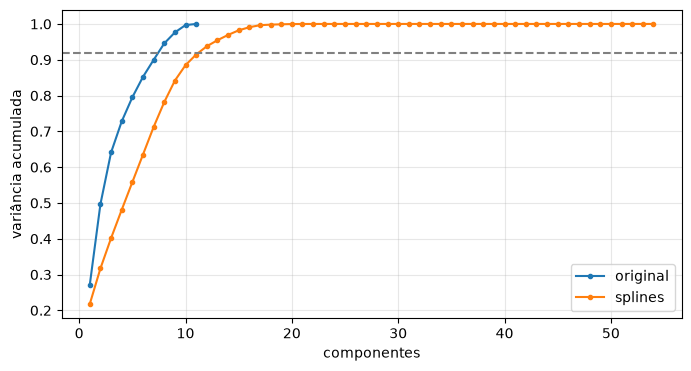

In [3]:
# sem padronizar, total sulfur dioxide (~100) dominaria density (~1)
pca_orig = PCA().fit(StandardScaler().fit_transform(X_orig))
pca_spl = PCA().fit(StandardScaler().fit_transform(X_spl))

var_orig = pd.Series(pca_orig.explained_variance_ratio_, index=range(1, X_orig.shape[1] + 1))
var_spl = pd.Series(pca_spl.explained_variance_ratio_, index=range(1, X_spl.shape[1] + 1))

tab = pd.DataFrame({'original': var_orig, 'orig acum': var_orig.cumsum(),
                    'splines': var_spl, 'spl acum': var_spl.cumsum()})
display(tab.head(20).round(4))

plt.figure(figsize=(8, 4))
plt.plot(var_orig.cumsum(), marker='.', label='original')
plt.plot(var_spl.cumsum(), marker='.', label='splines')
plt.axhline(0.92, color='gray', ls='--')
plt.xlabel('componentes')
plt.ylabel('variância acumulada')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Resposta 1:** no original a variância fica bem espalhada: o 1º componente explica uns 27%, o 2º uns 22%, e precisa de quase todos pra chegar perto de 100%. Ou seja, as 11 variáveis químicas trazem informação diferente entre si.

Nas splines o 1º componente explica uns 22% e é praticamente só açúcar (`residual sugar`, `ln_sugar_2`, `ln_sugar_3`, `ln_sugar_4` com o mesmo peso). A curva chega em 99,9% com uns 20 componentes e depois do 30º a variância é zero, então das 54 colunas só 30 trazem algo novo. O resto é coluna zerada ou combinação de outras.

#### 3- Loop até passar de 0,92

In [4]:
def n_comp(pca, limite=0.92):
    acum = 0
    for n, v in enumerate(pca.explained_variance_ratio_, start=1):
        acum += v
        if acum > limite:
            return n
    # se o limite for 1.0 o acumulado pode parar em 0.9999... por arredondamento
    return len(pca.explained_variance_ratio_)

for nome, pca, X in [('original', pca_orig, X_orig), ('splines', pca_spl, X_spl)]:
    n = n_comp(pca)
    print(f'{nome}: {n} de {X.shape[1]} colunas ({pca.explained_variance_ratio_[:n].sum():.2%} da variância)')

original: 8 de 11 colunas (94.57% da variância)
splines: 12 de 54 colunas (93.76% da variância)


**Resposta 3:** o original precisa de **8 de 11** componentes, uma redução pequena. As splines precisam de **12 de 54**, quase 80% a menos.

Parece que o PCA funciona muito melhor nas splines, mas é porque as 43 colunas novas saíram todas de uma variável só (`residual sugar`). O PCA está basicamente desfazendo a redundância que a gente mesmo criou.

#### 2- O PCA é bom pras splines? E o ruído?

Pra responder olhamos qual coluna pesa mais em cada componente e quantos vinhos têm valor nela.

In [5]:
linhas = []
for i in range(10):
    pesos = pd.Series(pca_spl.components_[i], index=X_spl.columns).abs().sort_values(ascending=False)
    col = pesos.index[0]
    linhas.append([i + 1, round(var_spl[i + 1], 4), col, (X_spl[col] != 0).sum()])
display(pd.DataFrame(linhas, columns=['comp', 'variância', 'maior peso', 'vinhos com valor']).set_index('comp'))

display(df_spl.loc[df_spl['spl_ln_sugar_2_12'] != 0, ['color', 'residual sugar', 'quality']])

,variância,maior peso,vinhos com valor
comp,,,
1,0.2179,ln_sugar_3,5243
2,0.0992,spl_ln_sugar_2_1,1104
3,0.0846,spl_ln_sugar_2_2,620
4,0.0791,spl_ln_sugar_3_12,1
5,0.0774,spl_ln_sugar_3_4,10
6,0.0770,spl_ln_sugar_4_5,1
7,0.0770,spl_ln_sugar_2_6,1
8,0.0696,spl_ln_sugar_4_0,3309
9,0.0601,density,5320


,color,residual sugar,quality
4391,white,65.8,6


**Resposta 2:** ajuda em parte, mas não é a melhor escolha.

Ajuda porque as splines têm muita coluna redundante (o mesmo açúcar em várias potências e faixas) e o PCA junta isso em poucos componentes.

Mas tem problemas. O PCA é linear: cada componente é uma soma ponderada das colunas. A spline existe justamente pra modelar uma relação curva entre açúcar e qualidade, e misturando tudo numa combinação linear essa estrutura por faixas se perde e os componentes ficam sem significado. Além disso, as colunas de spline são quase todas zero e só "ligam" numa faixa de açúcar, que não é o tipo de dado em que o PCA vai bem. E o PCA não olha pra `quality`: ele busca variância, não o que ajuda a prever a nota.

Sobre ruído: o PCA trata qualquer variância como informação, inclusive outlier. A tabela acima mostra isso. O componente 4 (quase 8% da variância) vem das colunas `spl_ln_sugar_*_12`, que só têm valor pra **um vinho** (65,8 g/L de açúcar, muito acima do resto). Os componentes 5, 6 e 7 também são colunas com pouquíssimos vinhos. Somando, cerca de 31% da variância é gasta descrevendo uma dúzia de vinhos. Isso acontece porque o `StandardScaler` deixa toda coluna com desvio 1, então uma coluna com um único valor diferente de zero pesa igual a `alcohol`.

Obs: o enunciado fala em potências até a 8ª, mas o arquivo vai só até a 4ª. Com potências maiores os valores extremos crescem ainda mais e o problema piora.

#### 4- Método mais indicado

Teste: tirar as colunas zeradas e as que têm valor pra menos de 1% dos vinhos, e rodar o PCA de novo.

In [6]:
X_spl2 = X_spl.loc[:, (X_spl != 0).mean() >= 0.01]  # as zeradas tem 0% de valor != 0, entao saem aqui tambem
pca_spl2 = PCA().fit(StandardScaler().fit_transform(X_spl2))
print(f'{X_spl.shape[1]} -> {X_spl2.shape[1]} colunas')
print('componentes p/ 92%:', n_comp(pca_spl2), '| antes:', n_comp(pca_spl), '| original:', n_comp(pca_orig))

54 -> 27 colunas
componentes p/ 92%: 9 | antes: 12 | original: 8


**Resposta 4:** não tem uma resposta única, mas aqui faz mais sentido **selecionar features antes** e, se ainda precisar comprimir, usar **Kernel PCA**.

Como todas as colunas novas vêm do açúcar, não faz muito sentido "comprimir" colunas que nós mesmos criamos. Só tirando as vazias ou quase vazias o dataset cai pela metade e precisa de 9 componentes pros 92%, um a mais que o original (8). Ou seja, as splines quase não acrescentam informação além do próprio açúcar. Dá pra fazer isso com `VarianceThreshold` mais um filtro de correlação entre as potências, e as colunas continuam com significado.

Se a ideia for manter a relação não linear que a spline tenta capturar, o Kernel PCA (kernel RBF ou polinomial) consegue achar estruturas curvas que o PCA comum não vê. UMAP e t-SNE servem pra visualizar em 2D, mas não pra gerar features pra modelo (o t-SNE nem transforma dado novo).

**Utilize o dataset 'wines.csv'**

Uma ideia realmente interessante é a clusterização. Por vezes, podemos nos espantar com certos resultados. Aqui, você deve utilizar o dataset original e separar cada nota em um cluster. 

1- Validar os resultados do algoritmo Kmeans com o dataset original

2- Aplicar o método do Cotovelo e averiguar se o número de clusters apontados são iguais ao número de cluster que você tem de usar.

3- Utilizar o método da Silhueta e averiguar se o número de clusters apontados são iguais ao número de cluster que você tem de usar.

4- Explique os principais conceitos dos métodos das questões 2 e 3.

**Utilize o dataset 'logs_firewall.xlsx'**

A Università di Bologna tem cursos de graduação e pós graduação em enologia. Os grandes enólogos do mundo são os únicos que podem fazer o doutorado nesta renomada universidade. Esta instituição tem um contrato milionário com o Sr.Donald, onde todos os alunos poderiam comparecer uma semana a cada três meses para estudar as características, mecânicas de plantações, tecnologias, processos de confecção dos vinhos, entre outras matérias. Todos os professores, escanções extremamente bem conceituados, sempre estão presentes. 

Caso infortúnio, O Sr.Hafþór Júlíus Björnsson, mais conhecido como "o Montanha", chefe de segurança cibernética da empresa apertou o botão DEFCON-1 ao perceber que os servidores tinham sido 'hackeados'. Momento em que notou que os bancos de dados que continham as notas dos vinhos haviam sido alterados/deletados e o backup infectado por um Ransomware chamado "HUE HUE HUE BR". Aparentemente, os black-hats conseguiram alterar de 5% a 25% dos dados referentes aos vinhos tintos, antes que o Montanha conseguisse exterminar as conexões dos servidores. 

O Sr.Donald Shelby aproximou-se para falar com você sobre as políticas da empresa, criadas por sua esposa, que dispunham sobre o bem estar, ambiente não tóxico, agregação dos "colaboradores" ~pseudo escravos~ como familiares, dentre outros ideais da mesma seara. Em seguida incorporou o espírito de Don Corleone e proferiu uma de suas máximas ao falar "Política é saber a hora de puxar o gatilho".   

Uma regra clara da empresa dispõe sobre a impossibilidade de extrair datasets como arquivos e, toda vez que for utilizar os dados no Jupyter Notebook, deve ser realizado uma query no datalake. Ocorre que, 'sem querer querendo', você estava "desatento" e salvou os dados para estudos quando estivesse em casa. Nítido que se disse-se que havia copiado quaisquer dados seria torturado, por isso não poderia simplesmente colocá-los de volta no banco e, como não queria morrer, tinha de encontrar vias oblíquas para dirimir a questão. 

Erick Cartman, analista de infraestrutura, recebeu ordens para recuperar os dados a qualquer custo e, caso falhasse, seria devidamente penalizado ~executado~. Desolado, regado a fanta uva, com palavras arrastadas e chiadas, Erick lhe pediu ajuda. Com muita pena, pegou seu disquete que continha a cópia dos dados e o entregou, pedindo extrema confidencialidade.

Para sua surpresa, após ter a vida salva, receber aumentos salariais e bonificações, Erick te chantageou. "Agora pediram para eu analisar os logs do firewall que contém informações de acesso a servidores e descobrir os possíveis culpados. Eu não sei fazer isso não, 'ocê tá LOUKO'. Dá teus pulos aí se não eu te conto que você copia dados da empresa!!!"

Conhecedor de diversas técnicas para detecção de outliers, se lembrou de uma que já tinha experiência: Isolation Forest. 

1- Descubra o nome do responsável pelo o ataque.

**ps**: Recentemente houve um estudo estatístico que comprovou que existe um fator de risco em relação aos horários de acesso, são eles:  

Entre 09:00 às 12:00 o risco varia entre 0-10%

Entre 12:00 às 14:00 o risco varia entre 5-10%

Entre 14:00 às 19:00 o risco varia entre 0-10%

Entre 19:00 às 21:00 o risco varia entre 20-30%

Entre 21:00 às 23:00 o risco varia entre 40-50%

Entre 00:00 às 02:00 o risco varia entre 60-80%

Entre 02:00 às 06:00 o risco varia entre 80-100%

Entre 06:00 às 09:00 o risco varia entre 30-40%

**<u>Esse fator pode ser recriado usando o método 'random.uniform', com 'seed' = 64.</u>**